# Model aggregation & lifetime sanity checks (`test_models`)

Diagnostic notebook based on [`AAOD_error_attribution.ipynb`](AAOD_error_attribution.ipynb).

**Goals**
- Sanity-check per-model regional aggregation and BC+OA lifetime used in the AAOD error-attribution workflow.
- Inspect any mapped variable (default AAOD) for one model or all models.
- Compare regional model fields to **homogenized POLDER** and model precipitation to **GPCP**.
- Plot **emission / deposition flux maps** zoomed to source regions (`emi_BC_OA`, `dep_BC_OA`, plus `emi_total` / `dep_total` when available).

**Inputs (cell below)**
- `SAVE_FIGURE` — write PNGs under `figure/test_models/`.
- `MODEL_NAME` — one AeroCom model id, or `None` if looping.
- `LOOP_ALL_MODELS` — if `True`, run the check for every loaded model (**requires** `SAVE_FIGURE=True`).
- `MAP_VAR` — field to map / ensemble-plot (`abs550aer`, `SSA`, `MAC`, `od550aer`, …).
- `ENSEMBLE_REGION` — region for the ensemble bar/scatter vs POLDER (default `africa`).
- `LIFETIME_METHOD` — `load_emi` or `load_dep` (maps to AAOD `USE_DEPOSITION_FOR_LIFETIME=False/True`).
  Global τ uses spatial means: ⟨load_BC_OA⟩ / ⟨sink_BC_OA⟩ (not per-gridcell).

**Shared cache:** set `USE_AGG_CACHE=True` to load `tables/regional_seasonal_aggregates.parquet` (built by `python py/build_regional_aggregates.py`) and skip NetCDF aggregation. Spatial maps still load 2D fields on demand.
**Plots** are split into separate cells (global / ensemble / precip / regional fluxes).


In [ ]:
# =============================================================================
# Configuration
# =============================================================================
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)

project_root = Path('/scistor/guest/gbb083/AeroCom')
sys.path.insert(0, str(project_root / 'py'))
sys.path.insert(0, str(project_root / 'notebooks'))
import cameo_toolbox as ct
import aerocom_data
import notebook_setup as setup

# --- User inputs ---
SAVE_FIGURE = True

FIGURE_DIR = project_root / 'figure'
TABLE_DIR = project_root / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = FIGURE_DIR / 'test_models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOOP_ALL_MODELS = False          # if True, SAVE_FIGURE must be True

# Shared regional seasonal cache (py/build_regional_aggregates.py).
USE_AGG_CACHE = True
AGG_PARQUET = TABLE_DIR / 'regional_seasonal_aggregates.parquet'

MAP_VAR = 'abs550aer'             # map + ensemble variable (AAOD default)
# Common choices: 'abs550aer', 'SSA', 'MAC', 'od550aer', 'lifetime_BC_OA', 'precip'
ENSEMBLE_REGION = 'africa'        # region for ensemble vs POLDER comparison

# Align with AAOD_error_attribution USE_DEPOSITION_FOR_LIFETIME:
#   USE_DEPOSITION_FOR_LIFETIME=False  <->  LIFETIME_METHOD='load_emi'
#   USE_DEPOSITION_FOR_LIFETIME=True   <->  LIFETIME_METHOD='load_dep'
USE_DEPOSITION_FOR_LIFETIME = True   # match AAOD default
LIFETIME_METHOD = 'load_dep' if USE_DEPOSITION_FOR_LIFETIME else 'load_emi'
# Global lifetime uses spatial means (not gridcell-wise mean of load/sink):
#   load_emi:  tau = mean(load_BC_OA) / (mean(emi_BC_OA) * 86400)   [days]
#   load_dep:  tau = mean(load_BC_OA) / (mean(dep_BC_OA) * 86400)   [days]

# Optional: restrict global lifetime / map season (None = full 2010)
GLOBAL_TIME_SLICE = ('2010-01-01', '2010-12-31')
MAP_TIME_INDEX = 0                # which monthly step to show on the map (after time_slice)

# Species lists (same pattern as AAOD notebook / notebook_setup helpers)
LOAD_VARS = ['loadbc', 'loaddust', 'loadoa', 'loadso4', 'loadss']
EMI_VARS = ['emibc', 'emidust', 'emioa', 'emiso2', 'emiss']
DEP_TOTAL_VARS = ['depbc', 'depdust', 'depoa', 'depso4', 'depss']
BC_OA_LOAD = ['loadbc', 'loadoa']
BC_OA_EMI = ['emibc', 'emioa']
BC_OA_DEP = ['depbc', 'depoa']

VARIABLES = sorted(set([
    'abs550aer', 'od550aer', 'od440aer', 'od870aer', 'od865aer',
    'precip',
] + LOAD_VARS + EMI_VARS + DEP_TOTAL_VARS))


In [ ]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping NetCDF load')
else:

    EXCLUDE_MODELS = [
        'GEOS-i33p2-met2010_AP3-CTRL-2010',
        'GISS-ModelE2p1p1-OMA_AP3-CTRL-2010',
        'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010',
        # 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL',
        # 'NorESM2-met2010_AP3-CTRL-v3',
    ]
    print('Loading monthly NetCDF from AP3_processed_monthly...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )
    models = sorted(m for m in raw_data if m not in EXCLUDE_MODELS)
    print(f'Loaded {len(models)} models (excluded {len(EXCLUDE_MODELS)} listed)')
    models


USE_AGG_CACHE=True: skipping NetCDF load


In [ ]:
# Choose models
MODEL_NAME = 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL'   # e.g. 'CAM5_CTRL2016'; set None if LOOP_ALL_MODELS

# Shared region boxes from notebook_setup (same lon/lat/time as AAOD).
# Do not redefine boxes here — setup.REGIONS['outflow_af'] is the paper box.
SOURCE_REGIONS = ['africa', 'amazon']
OUTFLOW_REGION = 'outflow_af'
ANALYSIS_REGIONS = SOURCE_REGIONS + [OUTFLOW_REGION]
REGIONS = {name: setup.REGIONS[name] for name in ANALYSIS_REGIONS}

POLDER_HOMOGENIZE = True

# Validate loop / save policy
if LOOP_ALL_MODELS and not SAVE_FIGURE:
    raise ValueError('LOOP_ALL_MODELS=True requires SAVE_FIGURE=True')
if not LOOP_ALL_MODELS and not MODEL_NAME:
    raise ValueError('Set MODEL_NAME or enable LOOP_ALL_MODELS')

print('--- test_models config ---')
print(f'  SAVE_FIGURE                  = {SAVE_FIGURE}')
print(f'  MODEL_NAME                   = {MODEL_NAME}')
print(f'  LOOP_ALL_MODELS             = {LOOP_ALL_MODELS}')
print(f'  MAP_VAR                      = {MAP_VAR}')
print(f'  ENSEMBLE_REGION              = {ENSEMBLE_REGION}')
print(f'  USE_DEPOSITION_FOR_LIFETIME  = {USE_DEPOSITION_FOR_LIFETIME}')
print(f'  LIFETIME_METHOD              = {LIFETIME_METHOD}  '
      f'(AAOD USE_DEPOSITION_FOR_LIFETIME={USE_DEPOSITION_FOR_LIFETIME})')
print(f'  SOURCE_REGIONS               = {SOURCE_REGIONS}')
print(f'  ANALYSIS_REGIONS             = {ANALYSIS_REGIONS}')
_oa = setup.REGIONS[OUTFLOW_REGION]
print(f'  outflow_af box               = lon {_oa["lon_range"]}, lat {_oa["lat_range"]}'
      f'  ({_oa["surface_type"]}, edge_weighted={_oa["edge_weighted"]})')


--- test_models config ---
  SAVE_FIGURE                  = False
  MODEL_NAME                   = CAM5_CTRL2016
  LOOP_ALL_MODELS             = False
  MAP_VAR                      = abs550aer
  ENSEMBLE_REGION              = africa
  USE_DEPOSITION_FOR_LIFETIME  = True
  LIFETIME_METHOD              = load_dep  (AAOD USE_DEPOSITION_FOR_LIFETIME=True)
  SOURCE_REGIONS               = ['africa', 'amazon']
  ANALYSIS_REGIONS             = ['africa', 'amazon', 'outflow_af']
  outflow_af box               = lon (350, 15), lat (-15, 0)  (ocean, edge_weighted=True)


## Load monthly AeroCom data


In [ ]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: focus_models set in cache-load cell')
else:

    if not LOOP_ALL_MODELS:
        if MODEL_NAME not in models:
            # fuzzy help
            hits = [m for m in models if MODEL_NAME and MODEL_NAME.lower() in m.lower()]
            raise KeyError(
                f'MODEL_NAME={MODEL_NAME!r} not in loaded models. '
                f'Close matches: {hits[:10] or models[:10]}'
            )
        focus_models = [MODEL_NAME]
    else:
        focus_models = list(models)

    print(f'Focus models ({len(focus_models)}): {focus_models[:5]}{"..." if len(focus_models)>5 else ""}')


USE_AGG_CACHE=True: focus_models set in cache-load cell


## Normalize time, build BC+OA load/emi/dep (+ totals), derive SSA/MAC

BC+OA combinations use `require_all=True` (`emibc+emioa`, `depbc+depoa` via `setup.sum_deposition_datasets` for positive-sink deposition). Totals (`emi_total` / `dep_total` / `load_total`) use `require_all=False` so missing species are skipped.


In [ ]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping normalize/derived')
else:
    def _first_da(ds_or_da):
        if ds_or_da is None:
            return None
        if isinstance(ds_or_da, xr.Dataset):
            return ds_or_da[list(ds_or_da.data_vars)[0]]
        return ds_or_da


    def _as_dataset(da, name):
        if da is None:
            return None
        if isinstance(da, xr.Dataset):
            return da
        return da.to_dataset(name=name)


    def normalize_dataset_time(ds, var_hint=None):
        return aerocom_data.normalize_dataset_time(ds, var_hint=var_hint, year=2010)


    data = {}
    for m in models:
        normalized = {}
        for var, ds in raw_data[m].items():
            if ds is None:
                continue
            try:
                normalized[var] = normalize_dataset_time(ds, var_hint=f'{m}/{var}')
            except Exception as e:
                print(f'  skip {m}/{var}: {e}')

        # Totals: allow missing species
        normalized['load_total'] = setup.sum_datasets(
            normalized, LOAD_VARS, 'load_total', require_all=False
        )
        normalized['emi_total'] = setup.sum_datasets(
            normalized, EMI_VARS, 'emi_total', require_all=False
        )
        normalized['dep_total'] = setup.sum_deposition_datasets(
            normalized, DEP_TOTAL_VARS, 'dep_total', require_all=False
        )

        # BC+OA: require both species (same as AAOD)
        normalized['load_BC_OA'] = setup.sum_datasets(
            normalized, BC_OA_LOAD, 'load_BC_OA', require_all=True
        )
        normalized['emi_BC_OA'] = setup.sum_datasets(
            normalized, BC_OA_EMI, 'emi_BC_OA', require_all=True
        )
        normalized['dep_BC_OA'] = setup.sum_deposition_datasets(
            normalized, BC_OA_DEP, 'dep_BC_OA', require_all=True
        )

        if normalized['load_BC_OA'] is None or normalized['emi_BC_OA'] is None:
            miss = [k for k in (BC_OA_LOAD + BC_OA_EMI) if normalized.get(k) is None]
            print(f'  {m}: incomplete BC+OA load/emi (missing {miss}); '
                  f'load_BC_OA/emi_BC_OA set to None')
        if normalized['dep_BC_OA'] is None:
            miss = [k for k in BC_OA_DEP if normalized.get(k) is None]
            print(f'  {m}: incomplete BC+OA dep (missing {miss}); dep_BC_OA set to None')

        if 'precip' in normalized:
            normalized['precip'] = aerocom_data.normalize_precipitation_units(normalized['precip'])

        try:
            aligned = aerocom_data.align_model_grids(normalized, ref_var='od550aer', model_hint=m)
        except Exception:
            aligned = normalized

        for dvar in ('SSA', 'MAC', 'AE'):
            try:
                derived = aerocom_data.calculate_derived_var(aligned, m, dvar)
                if derived is not None:
                    aligned[dvar] = derived
            except Exception:
                pass
        data[m] = aligned

    n_emi = sum(1 for m in models if data[m].get('emi_BC_OA') is not None)
    n_dep = sum(1 for m in models if data[m].get('dep_BC_OA') is not None)
    n_emi_t = sum(1 for m in models if data[m].get('emi_total') is not None)
    n_dep_t = sum(1 for m in models if data[m].get('dep_total') is not None)
    print(f'Prepared data for {len(data)} models')
    print(f'  emi_BC_OA available: {n_emi}/{len(models)} (require_all={BC_OA_EMI})')
    print(f'  dep_BC_OA available: {n_dep}/{len(models)} (require_all={BC_OA_DEP})')
    print(f'  emi_total available: {n_emi_t}/{len(models)} (require_all=False)')
    print(f'  dep_total available: {n_dep_t}/{len(models)} (require_all=False)')
    _fm = focus_models[0]
    print(f'Example vars for {_fm}: {sorted(k for k, v in data[_fm].items() if v is not None)}')


USE_AGG_CACHE=True: skipping normalize/derived


## Regional masks and seasonal aggregation

Masks use `setup.REGIONS` lon/lat boxes for `ANALYSIS_REGIONS`. Regional lifetime follows `LIFETIME_METHOD` (load/emi or load/dep), matching AAOD `USE_DEPOSITION_FOR_LIFETIME`.


In [ ]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping regional aggregation')
else:
    # Template grid
    sample_model = next(
        m for m in models
        if data[m].get('od550aer') is not None or data[m].get('abs550aer') is not None
    )
    _tmpl_ds = data[sample_model].get('od550aer') or data[sample_model]['abs550aer']
    template = _first_da(_tmpl_ds).isel(time=0)
    print(f'Template grid from {sample_model}: {template.dims}')

    masks = setup.create_analysis_masks(template, ANALYSIS_REGIONS)
    print('Masks:', list(masks.keys()))


    def _as_da(obj, prefer_name=None):
        if obj is None:
            return None
        if isinstance(obj, xr.Dataset):
            if prefer_name and prefer_name in obj:
                return obj[prefer_name]
            return obj[list(obj.data_vars)[0]]
        return obj


    def aggregate_region(model_dict, var_name, region_name, return_time_series=False, skipna=False):
        """Seasonal (or monthly) regional mean for every model.

        Unwraps Datasets to DataArrays before ``ct.regional_aggregate`` (same as AAOD
        effective usage); region boxes/time come from ``setup.REGIONS`` via ``REGIONS``.
        """
        cfg = REGIONS[region_name]
        result = {}
        for model, model_data in model_dict.items():
            if model_data.get(var_name) is None:
                continue
            da = _as_da(model_data[var_name], prefer_name=var_name)
            try:
                result[model] = ct.regional_aggregate(
                    da, masks[region_name],
                    spatial='mean', edge_weighted=cfg['edge_weighted'],
                    time_slice=cfg['time_slice'], temporal='mean',
                    return_time_series=return_time_series, skipna=skipna,
                )
            except Exception as e:
                print(f'  agg fail {var_name} {model} {region_name}: {e}')
        return result


    def to_float(val):
        if val is None:
            return np.nan
        try:
            return float(np.asarray(val).item() if hasattr(np.asarray(val), 'item') else val)
        except Exception:
            try:
                return float(val)
            except Exception:
                return np.nan


    AGG_VARS = [
        'abs550aer', 'SSA', 'MAC', 'od550aer', 'precip',
        'load_BC_OA', 'emi_BC_OA', 'dep_BC_OA',
        'load_total', 'emi_total', 'dep_total',
    ]
    if MAP_VAR not in AGG_VARS:
        AGG_VARS.append(MAP_VAR)

    model_seasonal = {r: {} for r in REGIONS}
    for region in REGIONS:
        for var in AGG_VARS:
            model_seasonal[region][var] = {
                m: to_float(v) for m, v in aggregate_region(data, var, region).items()
            }
        # Regional lifetime from aggregated load / active flux
        lt = {}
        for m in models:
            load = model_seasonal[region]['load_BC_OA'].get(m)
            if LIFETIME_METHOD == 'load_dep':
                flux = model_seasonal[region]['dep_BC_OA'].get(m)
            else:
                flux = model_seasonal[region]['emi_BC_OA'].get(m)
            if (
                load is not None and flux is not None
                and np.isfinite(load) and np.isfinite(flux) and flux != 0
            ):
                lt[m] = load / (flux * 86400.0)
        model_seasonal[region]['lifetime_BC_OA'] = lt

    print('Seasonal aggregation done.')
    print(f'  Regional lifetime method: {LIFETIME_METHOD} '
          f'(USE_DEPOSITION_FOR_LIFETIME={USE_DEPOSITION_FOR_LIFETIME})')
    for region in REGIONS:
        n = sum(np.isfinite(v) for v in model_seasonal[region].get(MAP_VAR, {}).values())
        n_lt = len(model_seasonal[region]['lifetime_BC_OA'])
        print(f'  {region}: {MAP_VAR} n={n}, lifetime_BC_OA n={n_lt}')


USE_AGG_CACHE=True: skipping regional aggregation


## Global lifetime (spatial-mean budget)

Computes a **single global lifetime** per model from spatial means (not the mean of per-gridcell lifetimes):

\[
\tau = \frac{\langle \mathrm{load\_BC\_OA}\rangle}{\langle \mathrm{sink}\rangle \cdot 86400}
\quad\text{(days)}
\]

with `sink = emi_BC_OA` (`LIFETIME_METHOD=load_emi`, AAOD `USE_DEPOSITION_FOR_LIFETIME=False`)
or `dep_BC_OA` (`LIFETIME_METHOD=load_dep`, AAOD `USE_DEPOSITION_FOR_LIFETIME=True`).


In [ ]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skip global 2D lifetime rebuild; use Plot lifetime table')
    global_lifetime_df = None
else:
    def global_spatial_mean(da, time_slice=None):
        """Area-weighted global mean (cos-lat); optional time mean over slice."""
        da = _as_da(da)
        if da is None:
            return np.nan
        if time_slice is not None and 'time' in da.dims:
            da = da.sel(time=slice(time_slice[0], time_slice[1]))
        # cos-lat weights
        lat_name = 'lat' if 'lat' in da.coords else 'latitude'
        lon_name = 'lon' if 'lon' in da.coords else 'longitude'
        weights = np.cos(np.deg2rad(da[lat_name]))
        weighted = da.weighted(weights)
        dims = [d for d in da.dims if d != 'time']
        spatial = weighted.mean(dim=dims, skipna=True)
        if 'time' in spatial.dims:
            spatial = spatial.mean(dim='time', skipna=True)
        return to_float(spatial)


    def global_lifetime_days(model_name, method=LIFETIME_METHOD, time_slice=GLOBAL_TIME_SLICE):
        md = data.get(model_name, {})
        load_m = global_spatial_mean(md.get('load_BC_OA'), time_slice)
        if method == 'load_emi':
            sink_m = global_spatial_mean(md.get('emi_BC_OA'), time_slice)
            sink_label = 'emi_BC_OA'
        elif method == 'load_dep':
            sink_m = global_spatial_mean(md.get('dep_BC_OA'), time_slice)
            sink_label = 'dep_BC_OA'
        else:
            raise ValueError(f'Unknown LIFETIME_METHOD={method}')
        if not (np.isfinite(load_m) and np.isfinite(sink_m) and sink_m != 0):
            return dict(tau_days=np.nan, load=load_m, sink=sink_m, sink_label=sink_label)
        return dict(
            tau_days=load_m / (sink_m * 86400.0),
            load=load_m,
            sink=sink_m,
            sink_label=sink_label,
        )


    # Table for all models (quick overview)
    _gl_rows = []
    for m in models:
        gl = global_lifetime_days(m)
        _gl_rows.append({
            'model': m,
            'method': LIFETIME_METHOD,
            'tau_days': gl['tau_days'],
            'load_BC_OA': gl['load'],
            gl['sink_label']: gl['sink'],
        })
    global_lifetime_df = pd.DataFrame(_gl_rows).sort_values('model')
    print(f'Global lifetime via {LIFETIME_METHOD} (spatial means, time={GLOBAL_TIME_SLICE}):')
    print(global_lifetime_df.describe(include='all')[['tau_days']].to_string())
    print('\nFocus model(s):')
    print(global_lifetime_df[global_lifetime_df['model'].isin(focus_models)].to_string(index=False))


USE_AGG_CACHE=True: skip global 2D lifetime rebuild; use Plot lifetime table


## POLDER (homogenized) and GPCP


In [ ]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping POLDER/GPCP (from parquet)')
else:
    # --- POLDER ---
    polder_path = project_root / 'Data' / 'AP3_POLDER_Collocated' / 'POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet'
    polder_cols = ['time', 'longitude', 'latitude', 'AOD_550', 'AAOD_550', 'AOD_440', 'AOD_870']
    polder_df = pd.read_parquet(polder_path, columns=polder_cols)
    polder_df['time'] = pd.to_datetime(polder_df['time'])
    polder_df['SSA'] = 1.0 - polder_df['AAOD_550'] / polder_df['AOD_550']
    polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['SSA', 'AAOD_550', 'AOD_550'])
    print(f'POLDER rows: {len(polder_df)}')


    def polder_region_mask(df, lon_range, lat_range):
        lon_min, lon_max = lon_range
        lat_min, lat_max = lat_range
        if lon_min > lon_max:
            mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
        else:
            mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
        mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
        return mask_lon & mask_lat


    def sample_model_at_polder(model_da, polder_sub):
        da = _as_da(model_da)
        lat_name = 'lat' if 'lat' in da.coords else 'latitude'
        lon_name = 'lon' if 'lon' in da.coords else 'longitude'
        lat_vals = da[lat_name].values
        lon_vals = da[lon_name].values
        # nearest index
        lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
        lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
        if 'time' in da.dims:
            # seasonal mean field for sampling
            cfg_ts = None
            vals = da.mean(dim='time', skipna=True).values
        else:
            vals = da.values
        sampled = vals[lat_idx, lon_idx]
        w = np.cos(np.deg2rad(polder_sub['latitude'].values))
        ok = np.isfinite(sampled) & np.isfinite(w)
        if not ok.any():
            return np.nan
        return float(np.average(sampled[ok], weights=w[ok]))


    def homogenize_obs(region, obs_col, model_var_key):
        """Zhong-style: sampled = a*regional + b → obs_regional = (obs_sampled - b)/a."""
        cfg = REGIONS[region]
        season = (polder_df['time'] >= cfg['time_slice'][0]) & (polder_df['time'] <= cfg['time_slice'][1])
        sub = polder_df.loc[season & polder_region_mask(polder_df, cfg['lon_range'], cfg['lat_range'])]
        if sub.empty:
            return np.nan, {'skipped': True}
        w = np.cos(np.deg2rad(sub['latitude']))
        obs_sampled = float(np.average(sub[obs_col], weights=w))
        if region == 'outflow_af' or not POLDER_HOMOGENIZE:
            return obs_sampled, {'homogenized': False, 'obs_sampled': obs_sampled}

        xs, ys = [], []
        for m in models:
            da = data[m].get(model_var_key)
            if da is None:
                continue
            # seasonal-mean field for sampling
            da0 = _as_da(da, model_var_key)
            try:
                da_season = da0.sel(time=slice(cfg['time_slice'][0], cfg['time_slice'][1])).mean('time', skipna=True)
            except Exception:
                continue
            reg = model_seasonal[region].get(model_var_key, {}).get(m)
            samp = sample_model_at_polder(da_season, sub)
            if np.isfinite(reg) and np.isfinite(samp):
                xs.append(reg); ys.append(samp)
        if len(xs) < 4:
            return obs_sampled, {'homogenized': False, 'obs_sampled': obs_sampled, 'n': len(xs)}
        a, b = np.polyfit(xs, ys, 1)
        homog = (obs_sampled - b) / a if a != 0 else np.nan
        return float(homog), {'homogenized': True, 'obs_sampled': obs_sampled, 'a': a, 'b': b, 'n': len(xs)}


    # Map MAP_VAR → POLDER column when possible
    POLDER_VAR_MAP = {
        'abs550aer': ('AAOD_550', 'abs550aer'),
        'SSA': ('SSA', 'SSA'),
        'od550aer': ('AOD_550', 'od550aer'),
    }

    aaod_obs_by_region = {}
    ssa_obs_by_region = {}
    for region in REGIONS:
        aaod_obs_by_region[region], _ = homogenize_obs(region, 'AAOD_550', 'abs550aer')
        ssa_obs_by_region[region], _ = homogenize_obs(region, 'SSA', 'SSA')
        print(f'  {region}: AAOD_obs={aaod_obs_by_region[region]:.5f}, SSA_obs={ssa_obs_by_region[region]:.5f}')

    # --- GPCP ---
    gpcp_path = project_root / 'Data' / 'Prec' / 'GPCP_2010_0-360.nc'
    gpcp = xr.open_dataset(gpcp_path)
    gpcp_precip = gpcp['sat_gauge_precip']
    print(f'GPCP: {gpcp_precip.dims} {gpcp_precip.shape}')


    def gpcp_region_mean(precip_da, region_name):
        cfg = REGIONS[region_name]
        lon_min, lon_max = cfg['lon_range']
        lat_min, lat_max = cfg['lat_range']
        t0, t1 = cfg['time_slice']
        sub = precip_da.sel(time=slice(t0, t1))
        if lon_min > lon_max:
            sub = xr.concat([sub.sel(lon=slice(lon_min, 360)), sub.sel(lon=slice(0, lon_max))], dim='lon')
        else:
            sub = sub.sel(lon=slice(lon_min, lon_max))
        sub = sub.sel(lat=slice(lat_max, lat_min))  # GPCP lat decreasing
        w = np.cos(np.deg2rad(sub['lat']))
        return sub.weighted(w).mean(dim=('lat', 'lon'), skipna=True)


    gpcp_region = {region: gpcp_region_mean(gpcp_precip, region) for region in REGIONS}
    print('GPCP seasonal means (mm/day):')
    for region, da in gpcp_region.items():
        print(f'  {region}: {float(da.mean()):.3f}')


USE_AGG_CACHE=True: skipping POLDER/GPCP (from parquet)


In [ ]:
# ---------------------------------------------------------------------------
# Load shared regional seasonal cache (optional)
# ---------------------------------------------------------------------------
from build_regional_aggregates import (
    load_agg_cache, rows_to_model_seasonal, rows_to_obs_dicts,
    gpcp_seasonal_to_region_series, DEFAULT_OUT,
)

if USE_AGG_CACHE:
    _agg_path = Path(AGG_PARQUET)
    print(f'Loading aggregate cache: {_agg_path}')
    agg_df = load_agg_cache(_agg_path)
    model_seasonal = rows_to_model_seasonal(agg_df, regions=list(ANALYSIS_REGIONS))
    _extra = [r for r in agg_df['region'].unique() if r not in model_seasonal]
    if _extra:
        model_seasonal.update(rows_to_model_seasonal(agg_df, regions=_extra))
    models = sorted({
        m for reg in model_seasonal.values()
        for vm in reg.values() for m in vm
    })
    # Optional exclusion (keep in sync with AAOD if defined)
    if 'EXCLUDE_MODELS' in dir() and EXCLUDE_MODELS:
        _ex = set(EXCLUDE_MODELS)
        for _reg, _vmap in list(model_seasonal.items()):
            for _var, _mmap in list(_vmap.items()):
                for _m in list(_mmap):
                    if _m in _ex:
                        del _mmap[_m]
        models = [m for m in models if m not in _ex]
    if not LOOP_ALL_MODELS:
        if MODEL_NAME not in models:
            hits = [m for m in models if MODEL_NAME and MODEL_NAME.lower() in m.lower()]
            raise KeyError(f'MODEL_NAME={MODEL_NAME!r} not in cache. Matches: {hits[:10]}')
        focus_models = [MODEL_NAME]
    else:
        focus_models = list(models)
    aaod_obs_by_region, ssa_obs_by_region, _gpcp_seasonal, polder_sampled = rows_to_obs_dicts(
        agg_df, regions=list(ANALYSIS_REGIONS)
    )
    gpcp_region = gpcp_seasonal_to_region_series(_gpcp_seasonal)
    # Spatial maps still need per-model NetCDF for 2D fields (loaded on demand below).
    data = {}
    print(f'Cache models={len(models)}; focus={focus_models}')
    for region in ANALYSIS_REGIONS:
        print(
            f'  {region}: AAOD_obs={aaod_obs_by_region.get(region, float("nan")):.5f}, '
            f'GPCP={_gpcp_seasonal.get(region, float("nan")):.3f}, '
            f'n_lt={len(model_seasonal.get(region, {}).get("lifetime_BC_OA", {}))}'
        )
else:
    print('USE_AGG_CACHE=False: using full in-notebook pipeline')


Loading aggregate cache: /scistor/guest/gbb083/AeroCom/tables/regional_seasonal_aggregates.parquet
Cache models=28; focus=['CAM5_CTRL2016']
  africa: AAOD_obs=0.07277, GPCP=1.105, n_lt=12
  amazon: AAOD_obs=0.02894, GPCP=1.896, n_lt=12
  outflow_af: AAOD_obs=0.07639, GPCP=0.294, n_lt=12


In [ ]:
agg_df


,region,time_start,time_end,lon_min,lon_max,lat_min,lat_max,surface_type,dataset,var,source,value,unit,area
0,global,2010-01-01,2010-12-31,0.0,360.0,-90.0,90.0,all,CAM5-ATRAS_AP3-CTRL,abs550aer,aggregated,0.003370,1,1.553604e+11
1,global,2010-01-01,2010-12-31,0.0,360.0,-90.0,90.0,all,CAM5-ATRAS_AP3-CTRL,od440aer,aggregated,0.120426,1,1.553604e+11
2,global,2010-01-01,2010-12-31,0.0,360.0,-90.0,90.0,all,CAM5-ATRAS_AP3-CTRL,od550aer,aggregated,0.105927,1,1.553604e+11
3,global,2010-01-01,2010-12-31,0.0,360.0,-90.0,90.0,all,CAM5-ATRAS_AP3-CTRL,od870aer,aggregated,0.084113,1,1.553604e+11
4,global,2010-01-01,2010-12-31,0.0,360.0,-90.0,90.0,all,CAM5-ATRAS_AP3-CTRL,od550bc,aggregated,0.002370,1,1.553604e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9045,boreal_na,2010-06-01,2010-08-31,242.0,258.0,52.0,63.0,land,GPCP,precip,aggregated,2.170161,mm day-1,NaN
9046,eastern_siberia,2010-07-01,2010-07-31,120.0,170.0,50.0,65.0,land,GPCP,precip,aggregated,2.631190,mm day-1,NaN
9047,west_russia,2010-07-15,2010-09-10,33.0,52.0,51.0,60.0,land,GPCP,precip,aggregated,1.782610,mm day-1,NaN
9048,boreal_na_west,2010-06-15,2010-08-31,242.0,258.0,52.0,63.0,land,GPCP,precip,aggregated,2.408893,mm day-1,NaN


## Per-model sanity-check plots


In [ ]:
def short_model_name(model):
    name = str(model)
    for suffix in (
        '_AP3-CTRL2016-PD', '_AP3-CTRL2016', '_AP3-CTRL-2010',
        '_AP3-CTRL2019', '_AP3-CTRL', '-met2010',
    ):
        name = name.replace(suffix, '')
    return name


def _save_or_show(fig, path):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    if SAVE_FIGURE:
        fig.savefig(path, dpi=200)  # no tight bbox — Cartopy maps get cropped
        print(f'  Saved: {path}')
        plt.close(fig)
    else:
        plt.show()


def plot_variable_map(model_name, var_name=MAP_VAR, time_index=MAP_TIME_INDEX):
    md = data[model_name]
    if md.get(var_name) is None:
        print(f'  No {var_name} for {model_name}')
        return None
    da = _as_da(md[var_name], var_name)
    if GLOBAL_TIME_SLICE and 'time' in da.dims:
        da = da.sel(time=slice(GLOBAL_TIME_SLICE[0], GLOBAL_TIME_SLICE[1]))
    if 'time' in da.dims:
        n_t = da.sizes['time']
        ti = min(max(time_index, 0), n_t - 1)
        field = da.isel(time=ti)
        tlabel = str(pd.to_datetime(field.time.values).date()) if hasattr(field, 'time') else f't={ti}'
    else:
        field = da
        tlabel = 'static'
    lat = field['lat'].values if 'lat' in field.coords else field['latitude'].values
    lon = field['lon'].values if 'lon' in field.coords else field['longitude'].values
    region_boxes = {
        name: (cfg['lon_range'][0], cfg['lon_range'][1], cfg['lat_range'][0], cfg['lat_range'][1])
        for name, cfg in REGIONS.items()
    }
    fig = ct.fake_uba_map(
        lon=lon, lat=lat, c_array=np.ma.masked_invalid(np.asarray(field.values, dtype=float)),
        labels=f'{var_name}',
        title=f'{short_model_name(model_name)} — {var_name} ({tlabel})',
        region_boxes=region_boxes,
        show_region_labels=True,
        mycolor='RdYlBu_r',
        show=False,
    )
    if fig is None:
        fig = plt.gcf()
    _save_or_show(fig, FIG_DIR / f'map_{var_name}_{model_name}.png')
    return fig


def plot_ensemble_region(model_name, region=ENSEMBLE_REGION, var_name=MAP_VAR):
    """Bar/scatter of all models in region; label only the focus model; POLDER line if applicable."""
    vals = model_seasonal[region].get(var_name, {})
    if not vals:
        print(f'  No ensemble values for {var_name} in {region}')
        return None
    items = sorted((m, v) for m, v in vals.items() if np.isfinite(v))
    if not items:
        print(f'  All NaN for {var_name} in {region}')
        return None
    names = [m for m, _ in items]
    y = np.array([v for _, v in items], dtype=float)
    x = np.arange(len(names))
    focus_idx = names.index(model_name) if model_name in names else None

    fig, ax = plt.subplots(figsize=(12, 4.5))
    colors = ['#d62728' if m == model_name else '#9ecae1' for m in names]
    ax.bar(x, y, color=colors, width=0.8, alpha=0.9)
    if focus_idx is not None:
        ax.annotate(
            short_model_name(model_name),
            xy=(focus_idx, y[focus_idx]),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=10, fontweight='bold', color='#d62728',
            arrowprops=dict(arrowstyle='-', color='#d62728', lw=0.8),
        )

    # POLDER comparison when variable maps to AAOD/SSA/AOD
    obs_val = np.nan
    obs_label = None
    if var_name == 'abs550aer':
        obs_val = aaod_obs_by_region.get(region, np.nan)
        obs_label = 'POLDER AAOD (homogenized)' if region != 'outflow_af' else 'POLDER AAOD (sampled)'
    elif var_name == 'SSA':
        obs_val = ssa_obs_by_region.get(region, np.nan)
        obs_label = 'POLDER SSA (homogenized)' if region != 'outflow_af' else 'POLDER SSA (sampled)'
    if np.isfinite(obs_val):
        ax.axhline(obs_val, color='k', ls='--', lw=1.5, label=f'{obs_label}={obs_val:.4f}')
        ax.legend(loc='best', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([])  # only focus model labeled
    ax.set_ylabel(var_name)
    ax.set_xlabel('Models (alphabetical; only focus model labeled)')
    ax.set_title(
        f'{region}: ensemble {var_name} — highlight {short_model_name(model_name)}',
        fontweight='bold',
    )
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    _save_or_show(fig, FIG_DIR / f'ensemble_{region}_{var_name}_{model_name}.png')
    return fig


def plot_precip_vs_gpcp(model_name, region=ENSEMBLE_REGION):
    """Seasonal-mean model precip vs GPCP for all regions; highlight focus region + print table."""
    rows = []
    for region in REGIONS:
        mval = model_seasonal[region].get('precip', {}).get(model_name, np.nan)
        gval = float(gpcp_region[region].mean()) if region in gpcp_region else np.nan
        rows.append({'region': region, 'model_precip': mval, 'GPCP': gval,
                     'bias': mval - gval if np.isfinite(mval) and np.isfinite(gval) else np.nan})
    pdf = pd.DataFrame(rows)
    print(f'\nPrecipitation ({model_name}) vs GPCP [mm/day]:')
    print(pdf.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(pdf))
    w = 0.35
    ax.bar(x - w/2, pdf['model_precip'], width=w, label=short_model_name(model_name), color='#d62728', alpha=0.85)
    ax.bar(x + w/2, pdf['GPCP'], width=w, label='GPCP', color='0.45', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(pdf['region'], rotation=20, ha='right')
    ax.set_ylabel('Precipitation (mm day$^{-1}$)')
    ax.set_title(f'Seasonal precip: {short_model_name(model_name)} vs GPCP', fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    _save_or_show(fig, FIG_DIR / f'precip_vs_gpcp_{model_name}.png')
    return pdf, fig


def print_regional_lifetime_table(model_name):
    rows = []
    for region in REGIONS:
        load = model_seasonal[region]['load_BC_OA'].get(model_name, np.nan)
        emi = model_seasonal[region]['emi_BC_OA'].get(model_name, np.nan)
        dep = model_seasonal[region]['dep_BC_OA'].get(model_name, np.nan)
        lt_emi = model_seasonal[region]['lifetime_BC_OA'].get(model_name, np.nan)
        lt_dep = load / (dep * 86400.0) if np.isfinite(load) and np.isfinite(dep) and dep != 0 else np.nan
        rows.append({
            'region': region,
            'load_BC_OA': load,
            'emi_BC_OA': emi,
            'dep_BC_OA': dep,
            'tau_load_emi_d': lt_emi,
            'tau_load_dep_d': lt_dep,
            MAP_VAR: model_seasonal[region].get(MAP_VAR, {}).get(model_name, np.nan),
        })
    rdf = pd.DataFrame(rows)
    print(f'\nRegional aggregation — {model_name}:')
    print(rdf.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    return rdf


def run_model_sanity_check(model_name):
    print('\n' + '=' * 72)
    print(f'SANITY CHECK: {model_name}')
    print('=' * 72)

    gl = global_lifetime_days(model_name)
    print(f"Global lifetime ({LIFETIME_METHOD}): τ = {gl['tau_days']:.3f} d"
          f"  |  ⟨load⟩={gl['load']:.4e}  ⟨{gl['sink_label']}⟩={gl['sink']:.4e}")

    print_regional_lifetime_table(model_name)
    plot_variable_map(model_name, MAP_VAR)
    plot_ensemble_region(model_name, ENSEMBLE_REGION, MAP_VAR)
    plot_precip_vs_gpcp(model_name)
    return gl


print('Helpers ready: run_model_sanity_check(model_name)')


Helpers ready: run_model_sanity_check(model_name)


## Source-region flux maps (emission & deposition)

For the focus model, plot seasonal-mean flux fields zoomed to each `SOURCE_REGIONS` box:

1. **emi_BC_OA** — BC+OA emission (`emibc+emioa`, require_all)
2. **dep_BC_OA** — BC+OA deposition (positive-sink `depbc+depoa`, require_all)
3. **emi_total** / **dep_total** — sum of available species (`require_all=False`)

Uses `ct.uba_map_flex` (or cartopy fallback) with per-panel extent from `setup.REGIONS` lon/lat (small pad).


In [ ]:
# ---------------------------------------------------------------------------
# Reusable spatial map helper (regional zoom or global curved)
# ---------------------------------------------------------------------------
# Units: emission / deposition stay native AeroCom kg m^-2 s^-1 (same as notebook).
import cartopy.crs as ccrs


def _region_extent(region_name, pad=3.0):
    cfg = setup.REGIONS[region_name]
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    lat0 = max(lat_min - pad, -90)
    lat1 = min(lat_max + pad, 90)
    if lon_min > lon_max:
        return [lon_min - pad, lon_max + pad, lat0, lat1]
    return [lon_min - pad, lon_max + pad, lat0, lat1]


def _ensure_model_field(model_name, var_name):
    """Lazy-load one model variable from NetCDF for 2D maps (cache is scalars only)."""
    global data
    if 'data' not in dir() or data is None:
        data = {}
    if model_name not in data:
        data[model_name] = {}
    if data[model_name].get(var_name) is not None:
        return data[model_name][var_name]
    fpath = project_root / 'Data' / 'AP3_processed_monthly' / var_name / f'{model_name}_{var_name}_processed.nc'
    if not fpath.exists():
        # Combined products need in-memory pipeline
        return data[model_name].get(var_name)
    ds = xr.open_dataset(fpath, engine='netcdf4')
    ds = aerocom_data.standardize_dataset(ds, var_name).load()
    ds.close()
    ds = aerocom_data.normalize_dataset_time(ds, var_hint=f'{model_name}/{var_name}', year=2010)
    if var_name == 'precip':
        ds = setup.normalize_precipitation_units(ds)
    data[model_name][var_name] = ds
    return ds


def _as_da(obj, prefer_name=None):
    if obj is None:
        return None
    if isinstance(obj, xr.Dataset):
        if prefer_name and prefer_name in obj:
            return obj[prefer_name]
        return obj[list(obj.data_vars)[0]]
    return obj


def _seasonal_field(model_name, var_name, region_name=None):
    md_var = None
    if 'data' in dir() and data and model_name in data:
        md_var = data[model_name].get(var_name)
    if md_var is None:
        md_var = _ensure_model_field(model_name, var_name)
    if md_var is None:
        return None
    da = _as_da(md_var, prefer_name=var_name)
    if da is None:
        return None
    if region_name is not None:
        t0, t1 = REGIONS[region_name]['time_slice']
    elif GLOBAL_TIME_SLICE is not None:
        t0, t1 = GLOBAL_TIME_SLICE
    else:
        t0 = t1 = None
    if t0 is not None and 'time' in da.dims:
        da = da.sel(time=slice(t0, t1))
    if 'time' in da.dims:
        da = da.mean(dim='time', skipna=True)
    return da


def _subset_to_extent(da, extent):
    lon_min, lon_max, lat_min, lat_max = extent
    lon_name = 'lon' if 'lon' in da.coords else 'longitude'
    lat_name = 'lat' if 'lat' in da.coords else 'latitude'
    if lon_min > lon_max:
        left = da.sel({lon_name: slice(lon_min, 360)})
        right = da.sel({lon_name: slice(0, lon_max)})
        sub = xr.concat([left, right], dim=lon_name)
        lon = np.asarray(sub[lon_name].values)
        lon = np.where(lon < lon_min - 180, lon + 360, lon)
        sub = sub.assign_coords({lon_name: lon})
    else:
        sub = da.sel({lon_name: slice(lon_min, lon_max)})
    # lat may be descending
    lat = np.asarray(da[lat_name].values)
    if lat[0] > lat[-1]:
        sub = sub.sel({lat_name: slice(lat_max, lat_min)})
    else:
        sub = sub.sel({lat_name: slice(lat_min, lat_max)})
    return sub


def _save_or_show(fig, path):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    if fig is None:
        return
    if SAVE_FIGURE:
        fig.savefig(path, dpi=200)  # no tight bbox — Cartopy maps get cropped
        print(f'  Saved: {path}')
        plt.close(fig)
    else:
        plt.show()


def plot_spatial_var(
    model_name,
    var_name,
    regions=None,
    extent_mode='regions',
    vmin=None,
    vmax=None,
    cmap='YlOrRd',
    unit_label=None,
):
    """Plot one variable as regional multi-panel zoom or a single global curved map.

    Parameters
    ----------
    regions : list[str] or None
        Source regions for zoom panels (default SOURCE_REGIONS).
    extent_mode : {'regions', 'global'}
        ``regions`` → one panel per region (padded box). ``global`` → Robinson.
    vmin, vmax : float, optional
        Color limits (useful for extreme emission/deposition).
    unit_label : str, optional
        Colorbar label; default uses var name + native unit hint.
    """
    regions = list(regions or SOURCE_REGIONS)
    unit_label = unit_label or f'{var_name} (kg m$^{{-2}}$ s$^{{-1}}$)' if any(
        var_name.startswith(p) for p in ('emi', 'dep')
    ) else var_name

    if extent_mode == 'global':
        da = _seasonal_field(model_name, var_name, region_name=None)
        if da is None:
            print(f'  No {var_name} for {model_name}')
            return None
        fig = ct.uba_map_flex(
            data={var_name: da},
            title=f'{model_name} — {var_name} (global seasonal)',
            labels=('Longitude', 'Latitude'),
            cbar_title=unit_label,
            extent='global',
            projection_type='curved',
            gridline=True,
            vmin=vmin,
            vmax=vmax,
            mycolor=cmap,
            cbar_mode='single',
            num_levels=None,
            show=False,
        )
        _save_or_show(fig, FIG_DIR / f'global_{var_name}_{model_name}.png')
        return fig

    panels = {}
    extents = {}
    for region in regions:
        da = _seasonal_field(model_name, var_name, region_name=region)
        if da is None:
            continue
        ext = _region_extent(region)
        sub = _subset_to_extent(da, ext)
        panels[region] = sub
        extents[region] = ext
    if not panels:
        print(f'  No panels for {var_name} / {model_name}')
        return None
    fig = ct.uba_map_flex(
        data=panels,
        title=[f'{r}' for r in panels],
        labels=('Longitude', 'Latitude'),
        cbar_title=unit_label,
        extent=extents,
        projection_type='regular',
        gridline=True,
        vmin=vmin,
        vmax=vmax,
        mycolor=cmap,
        cbar_mode='each',
        num_levels=None,
        show=False,
    )
    _save_or_show(fig, FIG_DIR / f'flux_map_{var_name}_{model_name}.png')
    return fig


## Run checks


## Plot A — Global curved map (`MAP_VAR`)

Loads the 2D field on demand from NetCDF. Set `MAP_VMIN`/`MAP_VMAX` for extreme values.


In [ ]:
# --- Plot A: global map ---
MAP_VMIN = 0   # e.g. 0.0
MAP_VMAX = 1e-9   # e.g. 1e-10 for emissions
for m in focus_models:
    plot_spatial_var(
        m, MAP_VAR, extent_mode='global',
        vmin=MAP_VMIN, vmax=MAP_VMAX,
        cmap='RdYlBu_r',
        unit_label=MAP_VAR,
    )


  Saved: /scistor/guest/gbb083/AeroCom/figure/test_models/global_abs550aer_CAM5_CTRL2016.png


In [ ]:
ct.uba_map_flex(
            data={var_name: da},
            title=f'{model_name} — {var_name} (global seasonal)',
            labels=('Longitude', 'Latitude'),
            cbar_title=unit_label,
            extent='global',
            projection_type='curved',
            gridline=True,
            vmin=vmin,
            vmax=vmax,
            mycolor=cmap,
            cbar_mode='single',
            num_levels=None,
            show=False,
        )

## Plot B — Ensemble vs POLDER (optional)

Uses cached `model_seasonal` + `aaod_obs_by_region` / `ssa_obs_by_region`.


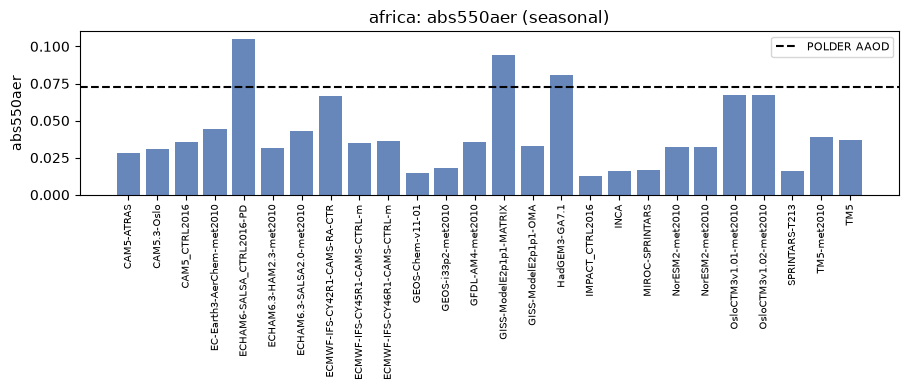

In [ ]:
# --- Plot B: ensemble bar (optional) ---
def plot_ensemble_region(region=ENSEMBLE_REGION, var_name=MAP_VAR):
    vals = model_seasonal.get(region, {}).get(var_name, {})
    if not vals:
        print(f'No {var_name} in model_seasonal[{region}]')
        return
    items = sorted(vals.items(), key=lambda kv: kv[0])
    names = [k.split('_AP3')[0][:28] for k, _ in items]
    y = [float(v) for _, v in items]
    fig, ax = plt.subplots(figsize=(max(8, len(y) * 0.35), 4))
    ax.bar(range(len(y)), y, color='#4C72B0', alpha=0.85)
    ax.set_xticks(range(len(y)))
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_ylabel(var_name)
    ax.set_title(f'{region}: {var_name} (seasonal)')
    if var_name in ('abs550aer',) and region in aaod_obs_by_region:
        ax.axhline(aaod_obs_by_region[region], color='k', ls='--', label='POLDER AAOD')
        ax.legend(fontsize=8)
    if var_name in ('SSA',) and region in ssa_obs_by_region:
        ax.axhline(ssa_obs_by_region[region], color='k', ls='--', label='POLDER SSA')
        ax.legend(fontsize=8)
    fig.tight_layout()
    _save_or_show(fig, FIG_DIR / f'ensemble_{region}_{var_name}.png')

plot_ensemble_region()


## Plot C — Model precip vs GPCP (optional)


            model_precip      gpcp
region                            
africa          0.769888  1.104894
amazon          1.663351  1.895703
outflow_af      0.277381  0.293575


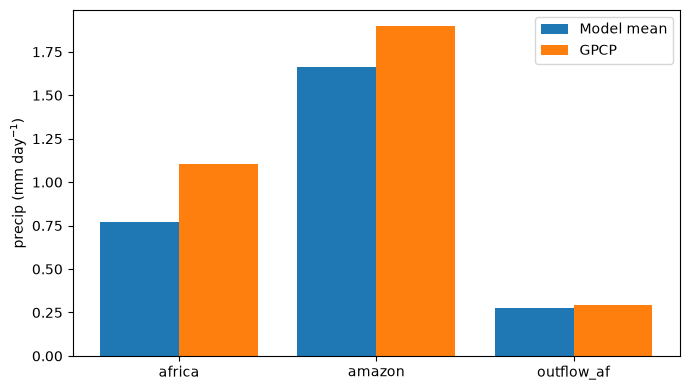

In [ ]:
# --- Plot C: precip vs GPCP ---
rows = []
for region in ANALYSIS_REGIONS:
    g = float(gpcp_region[region].values) if region in gpcp_region else np.nan
    for model, val in (model_seasonal.get(region, {}).get('precip') or {}).items():
        rows.append({'region': region, 'model': model, 'model_precip': float(val), 'gpcp': g})
pdf = pd.DataFrame(rows)
if pdf.empty:
    print('No precip in cache')
else:
    print(pdf.groupby('region')[['model_precip', 'gpcp']].mean())
    fig, ax = plt.subplots(figsize=(7, 4))
    regions = list(ANALYSIS_REGIONS)
    x = np.arange(len(regions))
    model_means = [pdf.loc[pdf.region == r, 'model_precip'].mean() for r in regions]
    gpcp_means = [pdf.loc[pdf.region == r, 'gpcp'].mean() for r in regions]
    ax.bar(x - 0.2, model_means, width=0.4, label='Model mean')
    ax.bar(x + 0.2, gpcp_means, width=0.4, label='GPCP')
    ax.set_xticks(x)
    ax.set_xticklabels(regions)
    ax.set_ylabel('precip (mm day$^{-1}$)')
    ax.legend()
    fig.tight_layout()
    _save_or_show(fig, FIG_DIR / 'precip_vs_gpcp.png')


## Plot D — Regional spatial maps (emission / deposition species)

Re-run with different `MAP_VARS`. Native units: **kg m⁻² s⁻¹**.


In [ ]:
# --- Plot D: regional flux / field maps ---
MAP_VARS = [
    'emibc', 'emioa',          # species emissions
    'depbc', 'depoa',        # species deposition
    # 'emi_BC_OA', 'dep_BC_OA',  # need full pipeline (combined) in `data`
]
FLUX_VMIN = None
FLUX_VMAX = None   # e.g. 1e-10
for m in focus_models:
    for var in MAP_VARS:
        plot_spatial_var(
            m, var, regions=SOURCE_REGIONS, extent_mode='regions',
            vmin=FLUX_VMIN, vmax=FLUX_VMAX, cmap='YlOrRd',
        )


  Saved: /scistor/guest/gbb083/AeroCom/figure/test_models/flux_map_emibc_CAM5_CTRL2016.png
  Saved: /scistor/guest/gbb083/AeroCom/figure/test_models/flux_map_emioa_CAM5_CTRL2016.png
  Saved: /scistor/guest/gbb083/AeroCom/figure/test_models/flux_map_depbc_CAM5_CTRL2016.png
  No panels for depoa / CAM5_CTRL2016


## Global lifetime table (from cache or in-memory)


In [ ]:
# --- Lifetime summary from cache ---
rows = []
for region in ANALYSIS_REGIONS:
    for model, val in (model_seasonal.get(region, {}).get('lifetime_BC_OA') or {}).items():
        rows.append({'region': region, 'model': model, 'lifetime_BC_OA': float(val)})
lt_df = pd.DataFrame(rows)
print(lt_df.groupby('region')['lifetime_BC_OA'].describe())
out_csv = TABLE_DIR / 'test_models_global_lifetime.csv'
# Prefer existing global_lifetime_df if full pipeline ran
if 'global_lifetime_df' in dir() and global_lifetime_df is not None and len(global_lifetime_df):
    global_lifetime_df.to_csv(out_csv, index=False)
    print(f'Wrote {out_csv} from global_lifetime_df')
else:
    lt_df.to_csv(out_csv, index=False)
    print(f'Wrote {out_csv} from cache lifetime_BC_OA')


            count       mean        std       min        25%        50%  \
region                                                                    
africa       12.0  17.700649  12.154583  5.020590   7.808171  14.560321   
amazon       12.0  13.037893   8.381371  4.650906   8.445349  10.476799   
outflow_af   10.0  20.480692  10.614898  8.560881  13.974689  17.658340   

                  75%        max  
region                            
africa      24.614554  41.927436  
amazon      14.829106  35.108533  
outflow_af  24.815775  42.269879  
Wrote /scistor/guest/gbb083/AeroCom/tables/test_models_global_lifetime.csv from cache lifetime_BC_OA


**Figure / output notes**

- **Global / regional lifetime** follows `LIFETIME_METHOD` (`load_emi` or `load_dep`), equivalent to AAOD `USE_DEPOSITION_FOR_LIFETIME=False/True`. Regional τ = aggregated load_BC_OA / (flux_BC_OA · 86400) with flux = emi or dep.
- **BC+OA fluxes** require both species (`emibc+emioa`, `depbc+depoa` via positive-sink `sum_deposition_datasets`). **Totals** (`emi_total` / `dep_total`) sum available species with `require_all=False`.
- **Map** shows `MAP_VAR` for the focus model with study-region boxes.
- **Flux maps** zoom to each `SOURCE_REGIONS` box for `emi_BC_OA`, `dep_BC_OA`, `emi_total`, and `dep_total` (seasonal mean over the region fire-season `time_slice`).
- **Ensemble plot** shows all models seasonal regional `MAP_VAR` in `ENSEMBLE_REGION`; only the focus model is labeled; dashed line is homogenized POLDER when `MAP_VAR` is AAOD or SSA.
- **Precip** compares seasonal regional model precipitation to GPCP for every study region.
